In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [4]:
data_raw = pd.read_csv('data/heart_disease_risk_dataset_earlymed.csv')

In [7]:
print('size: ',data_raw.shape)
data_raw.head()

size:  (70000, 19)


,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,48.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,46.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,66.0,0.0
3,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,60.0,1.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,69.0,0.0


In [8]:
data_raw.dtypes

Chest_Pain             float64
Shortness_of_Breath    float64
Fatigue                float64
Palpitations           float64
Dizziness              float64
Swelling               float64
Pain_Arms_Jaw_Back     float64
Cold_Sweats_Nausea     float64
High_BP                float64
High_Cholesterol       float64
Diabetes               float64
Smoking                float64
Obesity                float64
Sedentary_Lifestyle    float64
Family_History         float64
Chronic_Stress         float64
Gender                 float64
Age                    float64
Heart_Risk             float64
dtype: object

Se tienen 18 varaibles descriptivas de las cuales todas son binarias, que representan presencia o no presencia, sin embargo la variable edad es un valor entero.

In [15]:
print('duplicated rows: ', data_raw.duplicated().sum())
print('missing values: ', data_raw.isna().sum().sum())

duplicated rows:  0
missing values:  0


In [ ]:
data_raw.drop_duplicates(inplace=True)
print('duplicated rows: ', data_raw.duplicated().sum())

duplicated rows:  0


In [16]:
data_raw.describe()

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
count,63755.000000,63755.000000,63755.000000,63755.000000,63755.000000,63755.000000,63755.000000,63755.000000,63755.000000,63755.000000,63755.000000,63755.000000,63755.000000,63755.000000,63755.000000,63755.000000,63755.000000,63755.000000,63755.000000
mean,0.493891,0.495145,0.493514,0.493499,0.496839,0.493702,0.496636,0.497608,0.494502,0.495443,0.497655,0.499365,0.495726,0.500494,0.493797,0.495679,0.544757,54.328210,0.493875
std,0.499967,0.499980,0.499962,0.499962,0.499994,0.499964,0.499993,0.499998,0.499974,0.499983,0.499998,0.500004,0.499986,0.500004,0.499965,0.499985,0.497997,16.414121,0.499966
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,44.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,55.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,66.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,84.000000,1.000000


# Dataset

In [17]:
x = data_raw.drop(columns=['Heart_Risk'])
y = data_raw['Heart_Risk']

print('x shape: ', x.shape)
print('y shape: ', y.shape)

x shape:  (63755, 18)
y shape:  (63755,)


In [20]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print('x_train shape: ', x_train.shape)
print('x_test shape: ', x_test.shape)
print('y_train shape: ', y_train.shape)
print('y_test shape: ', y_test.shape)

x_train shape:  (51004, 18)
x_test shape:  (12751, 18)
y_train shape:  (51004,)
y_test shape:  (12751,)


# Model

In [42]:
tree_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=1)

tree_model.fit(x_train, y_train)


DecisionTreeClassifier(max_depth=4, random_state=1)

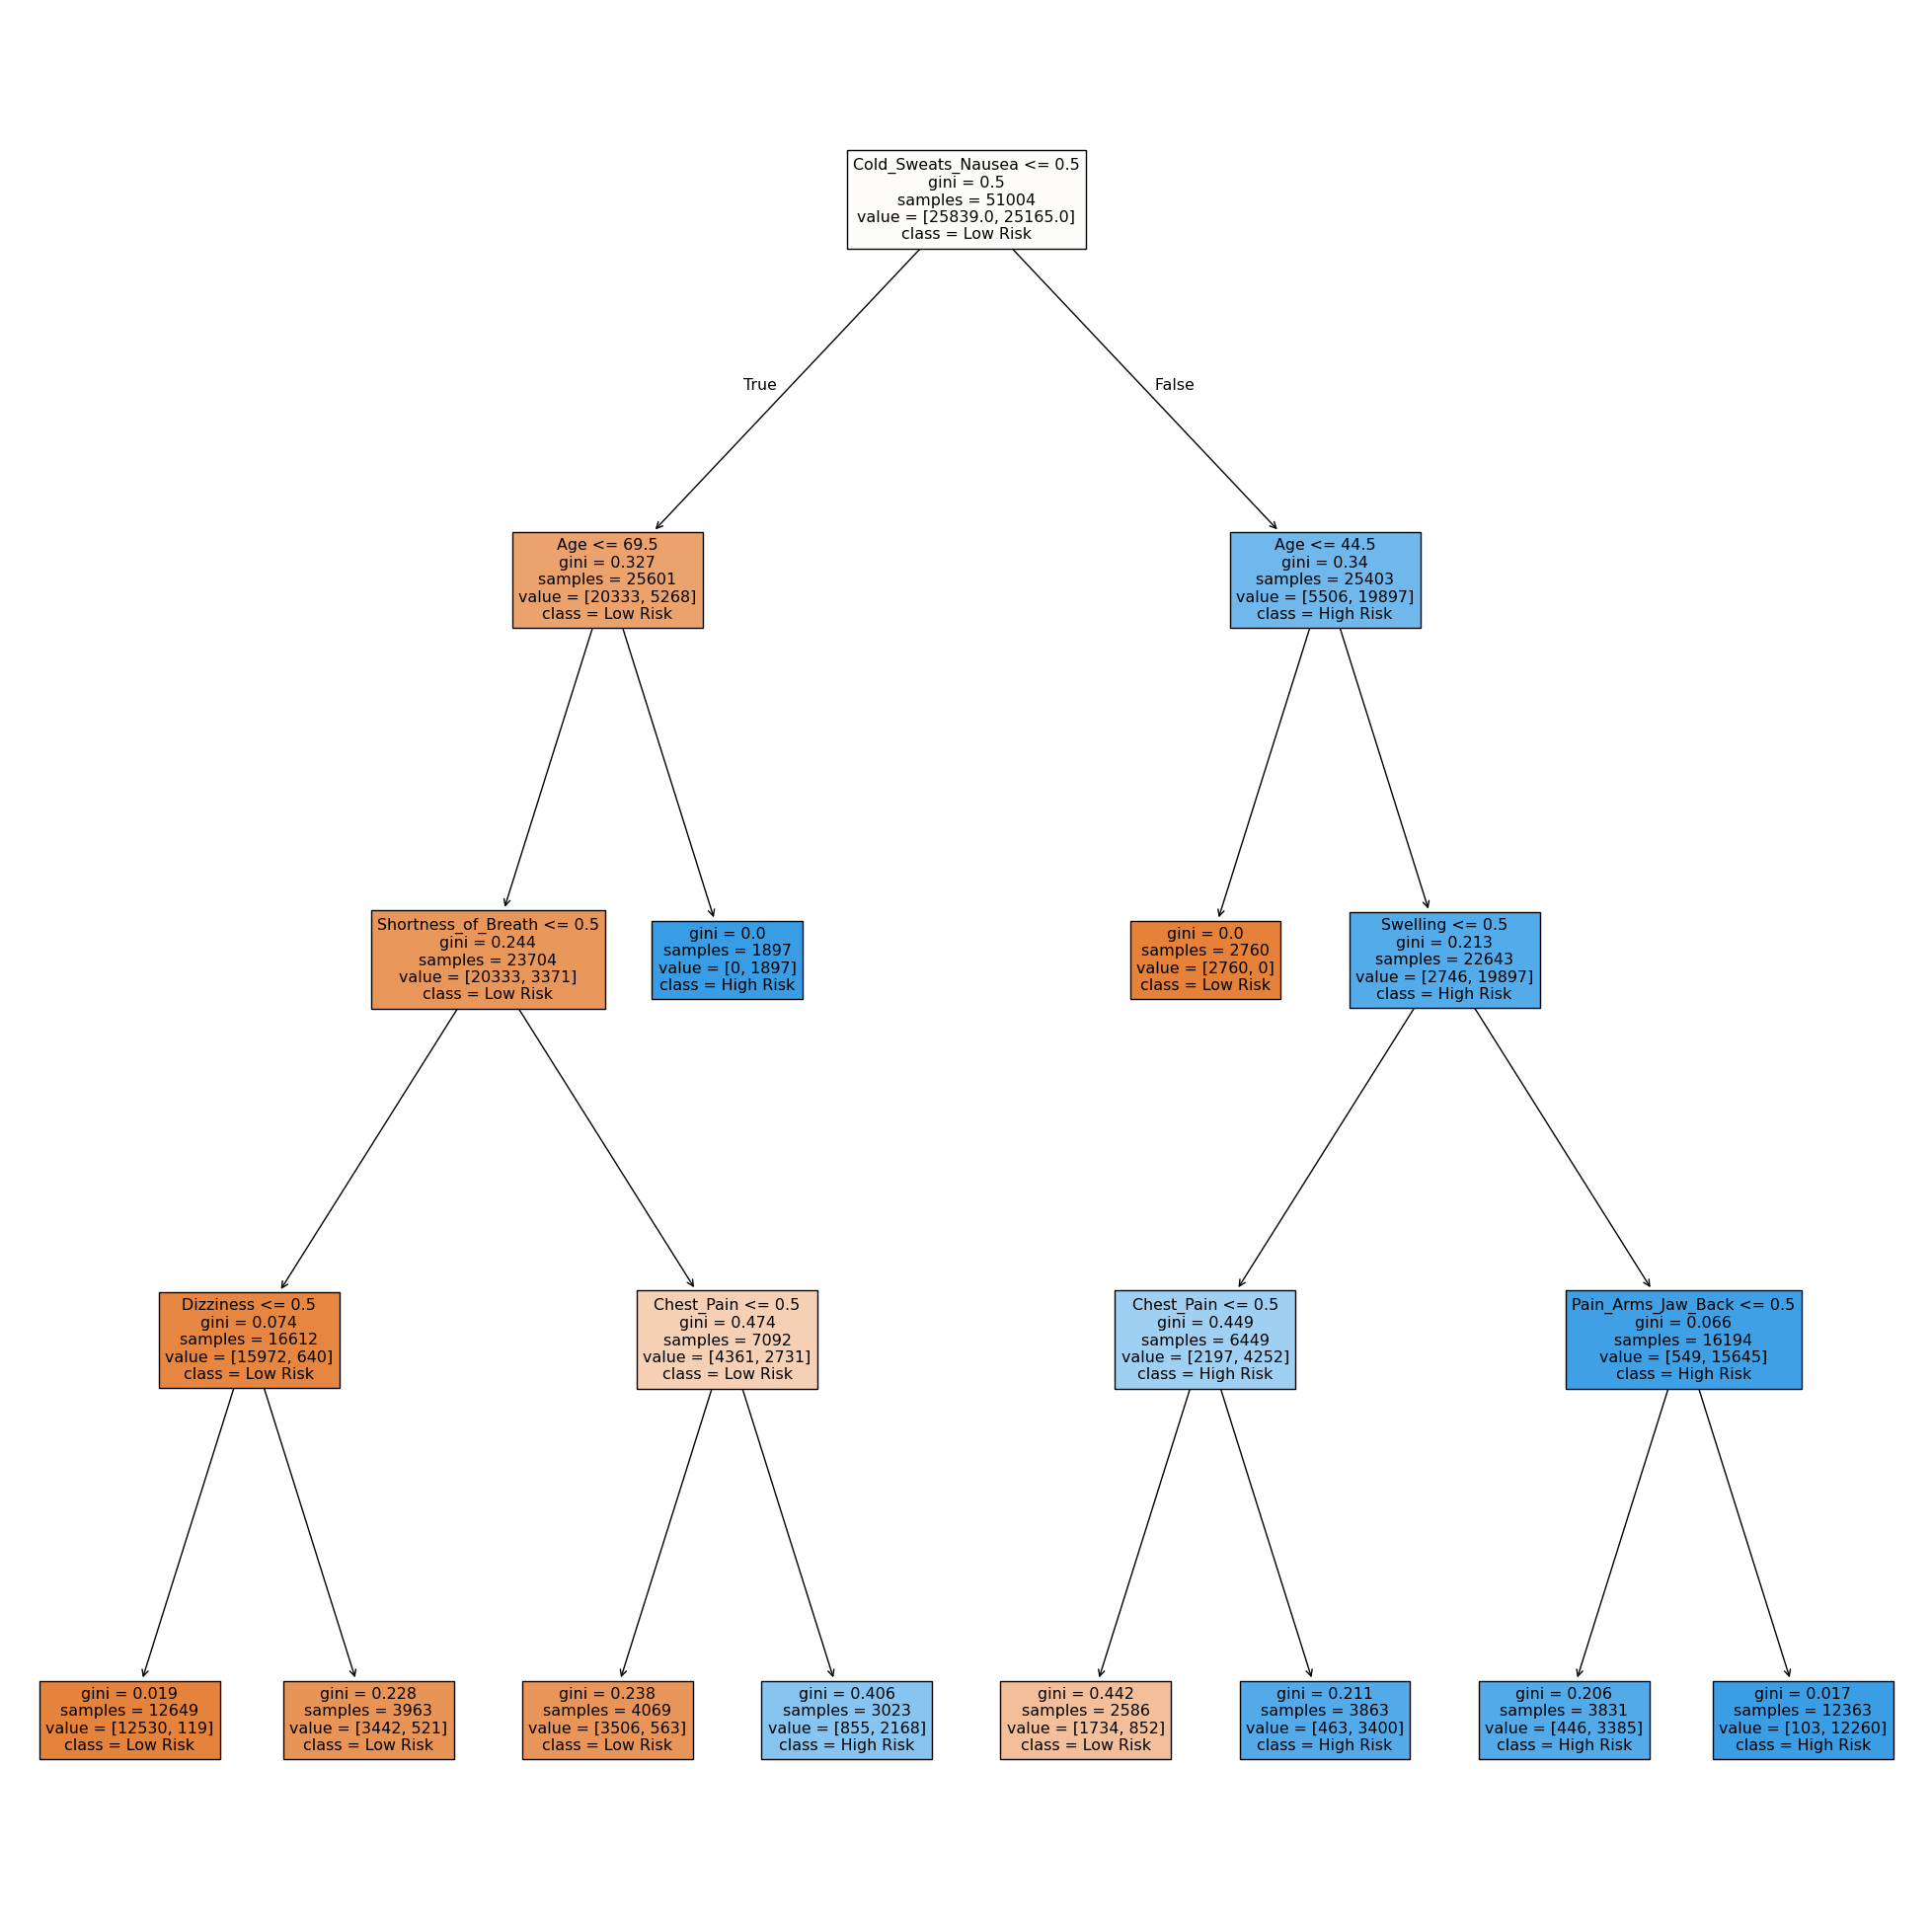

In [43]:
plt.figure(figsize=(25, 25))
plot_tree(tree_model, 
           feature_names=x.columns,
           class_names=['Low Risk', 'High Risk'],
           filled=True)
plt.show()

In [47]:
print('Testing accuracy: ', round(tree_model.score(x_test, y_test), 3))

Testing accuracy:  0.922


                Feature  Importance
7    Cold_Sweats_Nausea    0.442702
17                  Age    0.332324
0            Chest_Pain    0.109400
1   Shortness_of_Breath    0.062146
5              Swelling    0.045190
4             Dizziness    0.004680
6    Pain_Arms_Jaw_Back    0.003557
3          Palpitations    0.000000
2               Fatigue    0.000000
8               High_BP    0.000000
10             Diabetes    0.000000
11              Smoking    0.000000
12              Obesity    0.000000
13  Sedentary_Lifestyle    0.000000
14       Family_History    0.000000
15       Chronic_Stress    0.000000
16               Gender    0.000000
9      High_Cholesterol    0.000000


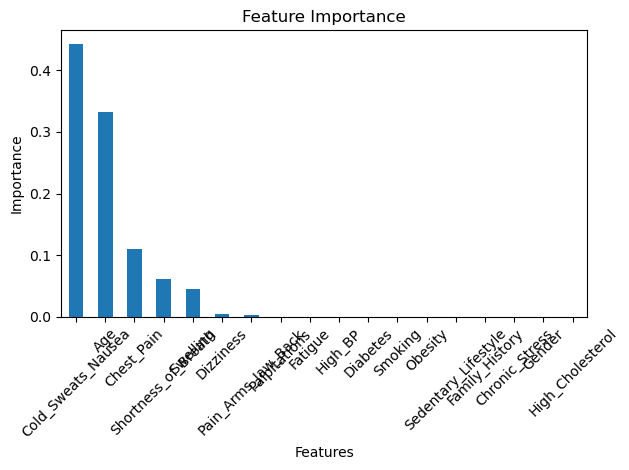

In [ ]:
# important features in decision tree
importance = tree_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)
print(importance_df)


# Logistic regresion


In [48]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C= 100.0, solver='lbfgs')
lr.fit(x_train, y_train)
print('Logistic Regression Testing accuracy: ', round(lr.score(x_test, y_test), 3))

Logistic Regression Testing accuracy:  0.993


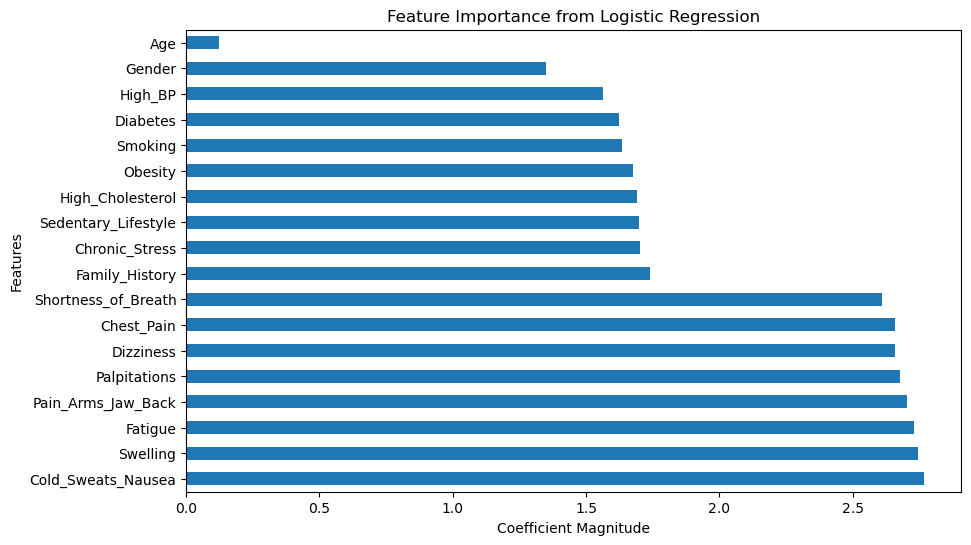

In [50]:
# important features in logistic regression
importance = pd.Series(np.abs(lr.coef_[0]), index=x.columns)
importance.sort_values(ascending=False, inplace=True)
# Plotting feature importance
importance.plot(kind='barh', figsize=(10, 6))
plt.title('Feature Importance from Logistic Regression')
plt.xlabel('Coefficient Magnitude')
plt.ylabel('Features')
plt.show()